### Домашняя работа №3 — Token Activation Map (TAM)

**Статья:** Li et al., *Token Activation Map to Visually Explain Multimodal LLMs*,
ICCV 2025 (Oral) (arXiv: 2506.23270; код: github.com/xmed-lab/TAM).



In [ ]:
!git clone -q https://github.com/xmed-lab/TAM.git
%cd TAM
!pip install -q -r requirements.txt
!pip uninstall -y fitz -q
!pip install -q --force-reinstall pymupdf
!pip install -q qwen-vl-utils
!apt-get -qq install -y texlive-latex-base texlive-latex-extra dvipng > /dev/null 2>&1 || echo "LaTeX failed; text-vis skipped, image heatmaps still work"

import os, torch, numpy as np
from PIL import Image
import matplotlib.pyplot as plt

/content/TAM
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 68.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.0/25.0 MB 61.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 25.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 72.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 47.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 110.7/110.7 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.9/425.9 kB 17.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 615.4/615.4 kB 20.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 47.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.3/36.3 MB 16.8 MB/s eta 0:00:00


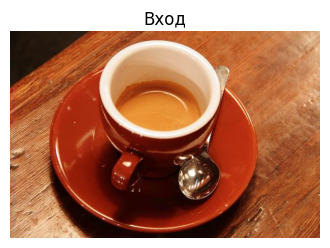

In [ ]:

from skimage import data
os.makedirs("imgs", exist_ok=True)
IMG_PATH = "imgs/demo.jpg"
Image.fromarray(data.coffee()).save(IMG_PATH)
PROMPT = "Describe this image in detail."

plt.figure(figsize=(4, 4)); plt.imshow(Image.open(IMG_PATH)); plt.axis("off")
plt.title("Вход"); plt.show()

In [ ]:
from transformers import Qwen2VLForConditionalGeneration, AutoProcessor
from qwen_utils import process_vision_info
MODEL = "Qwen/Qwen2-VL-2B-Instruct"
model = Qwen2VLForConditionalGeneration.from_pretrained(MODEL, torch_dtype="auto", device_map="auto")
processor = AutoProcessor.from_pretrained(MODEL)

messages = [{"role": "user", "content": [{"type": "image", "image": IMG_PATH},
                                         {"type": "text", "text": PROMPT}]}]
text = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
image_inputs, video_inputs = process_vision_info(messages)
inputs = processor(text=[text], images=image_inputs, videos=video_inputs,
                   padding=True, return_tensors="pt").to(model.device)

outputs = model.generate(**inputs, max_new_tokens=32, use_cache=True,
                         output_hidden_states=True,
                         return_dict_in_generate=True)
generated_ids = outputs.sequences
gen_only = generated_ids[0][inputs.input_ids.shape[1]:]
answer = processor.decode(gen_only, skip_special_tokens=True)
gen_words = [processor.decode([t], skip_special_tokens=True) for t in gen_only.tolist()]
print("Ответ модели:", answer)

config.json: 0.00B [00:00, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

model-00001-of-00002.safetensors:   0%|          | 0.00/3.99G [00:00<?, ?B/s]

model-00002-of-00002.safetensors:   0%|          | 0.00/429M [00:00<?, ?B/s]

...

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

You have video processor config saved in `preprocessor.json` file which is deprecated. Video processor configs should be saved in their own `video_preprocessor.json` file. You can rename the file or load and save the processor back which renames it automatically. Loading from `preprocessor.json` will be removed in v5.0.


chat_template.json: 0.00B [00:00, ?B/s]

Ответ модели: The image depicts a single espresso cup placed on a matching saucer. The cup is white with a red handle and a brown saucer. The espresso is visible


In [ ]:
!apt-get -qq install -y texlive-xetex > /dev/null 2>&1

In [ ]:
from tam import TAM

logits = [model.lm_head(feats[-1]) for feats in outputs.hidden_states]

special_ids = {'img_id': [151652, 151653],
               'prompt_id': [151653, [151645, 198, 151644, 77091]],
               'answer_id': [[198, 151644, 77091, 198], -1]}
vision_shape = (inputs['image_grid_thw'][0, 1] // 2, inputs['image_grid_thw'][0, 2] // 2)

SAVE = "vis_out"; os.makedirs(SAVE, exist_ok=True)
raw_map_records = []
for i in range(len(logits)):
    try:
        TAM(generated_ids[0].cpu().tolist(), vision_shape, logits, special_ids,
            image_inputs, processor, os.path.join(SAVE, f"{i}.jpg"),
            i, raw_map_records, False)
    except Exception as e:
        print(f"  токен {i}: TAM пропущен ({e})")
print("сохранено карт:", len(os.listdir(SAVE)))

сохранено карт: 31


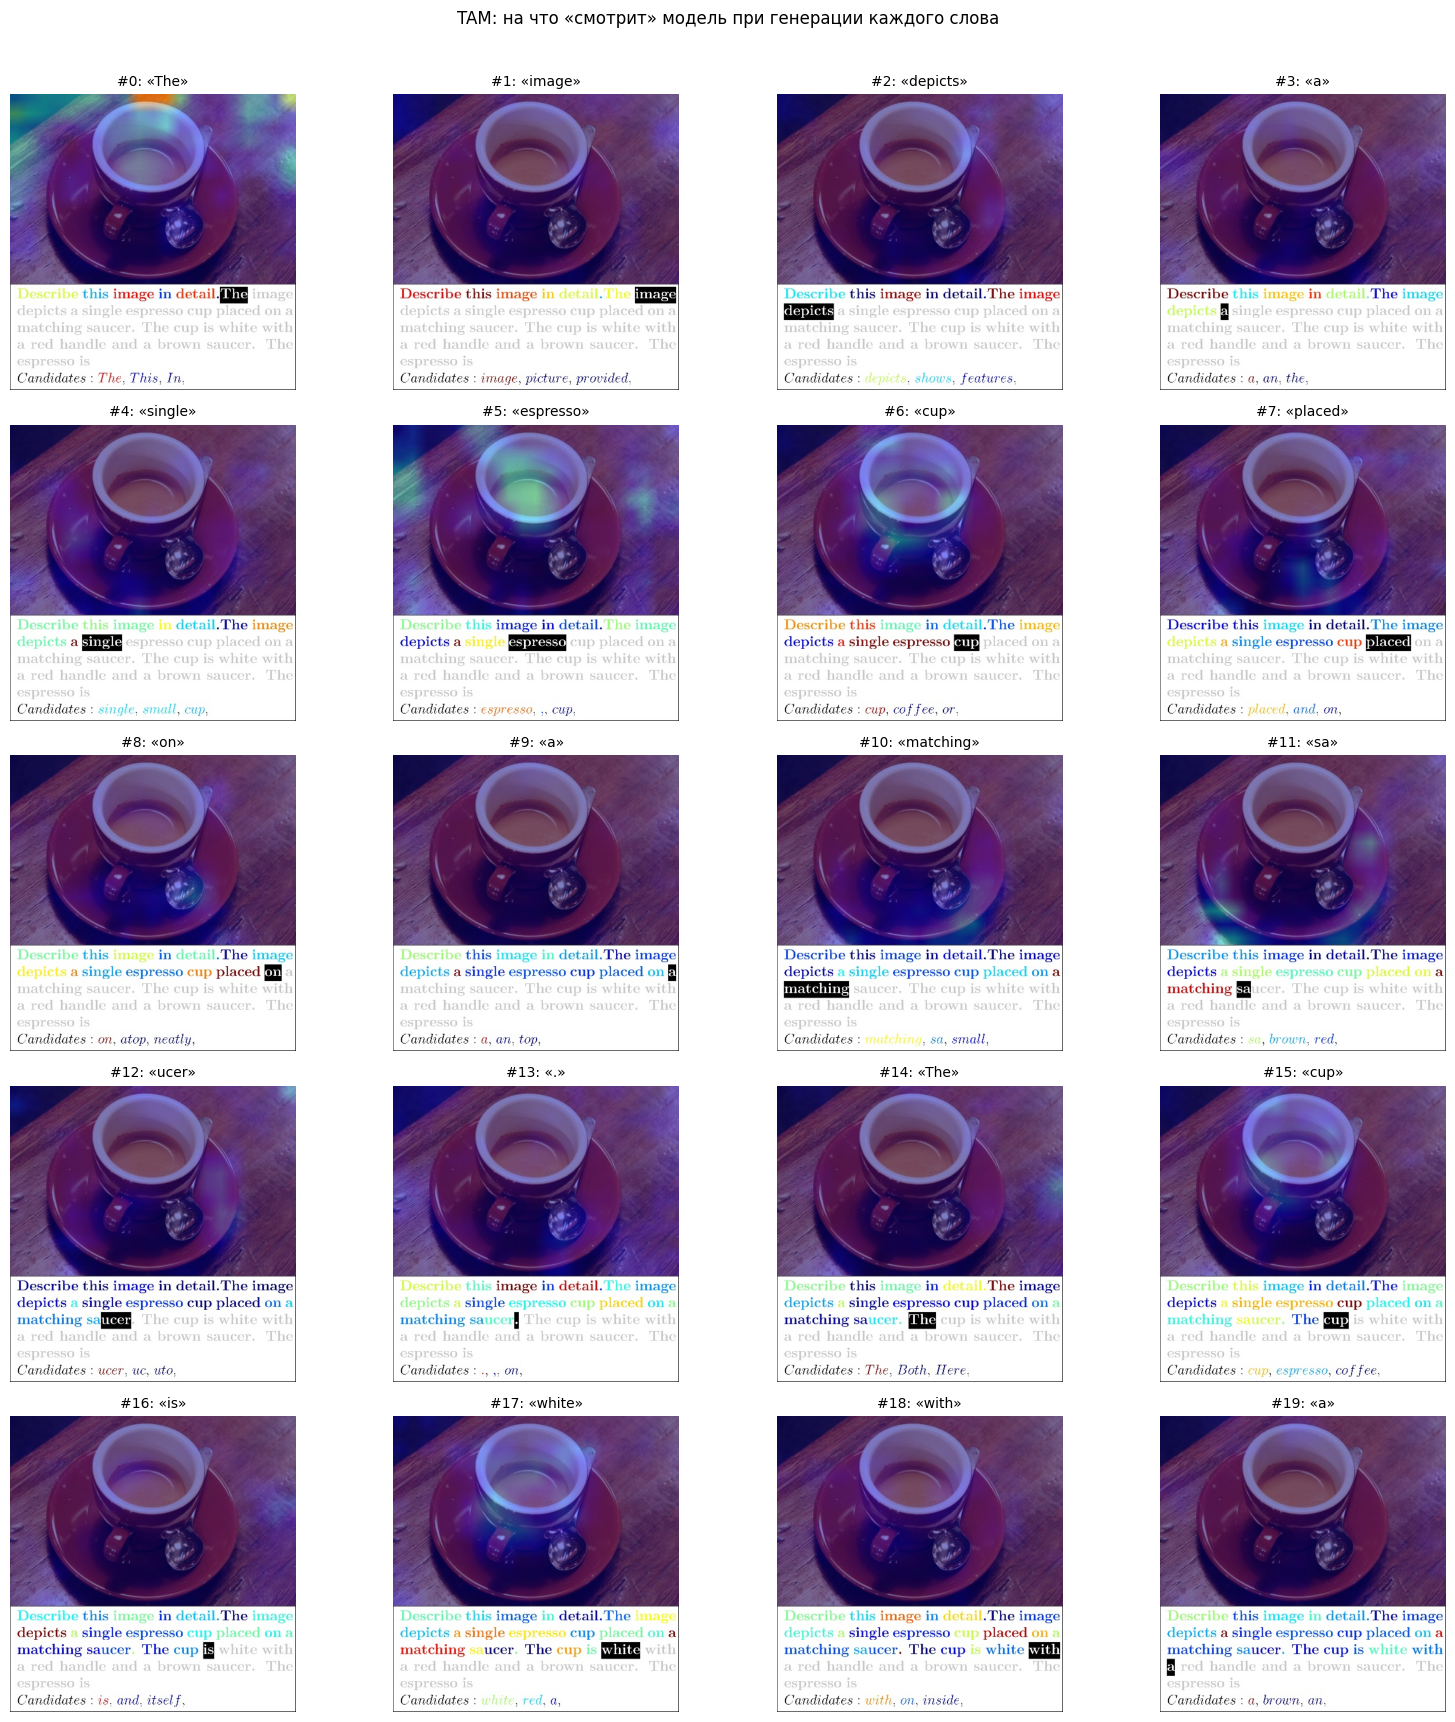

In [ ]:
saved = sorted([f for f in os.listdir(SAVE) if f.endswith(".jpg")],
               key=lambda s: int(s.split(".")[0]))
show = saved[:20]
cols = 4; rows = (len(show) + cols - 1) // cols
fig, ax = plt.subplots(rows, cols, figsize=(4 * cols, 3.4 * rows))
ax = np.atleast_2d(ax)
for k, fn in enumerate(show):
    r, c = divmod(k, cols)
    idx = int(fn.split(".")[0])
    ax[r, c].imshow(Image.open(os.path.join(SAVE, fn)))
    w = gen_words[idx] if idx < len(gen_words) else ""
    ax[r, c].set_title(f"#{idx}: «{w.strip()}»", fontsize=10)
for a in ax.ravel():
    a.axis("off")
plt.suptitle("TAM: на что «смотрит» модель при генерации каждого слова", y=1.01)
plt.tight_layout(); plt.savefig("/content/tam_grid.png", dpi=150, bbox_inches="tight"); plt.show()

### Анализ и вывод

Модель (Qwen2-VL-2B-Instruct) на запрос «Describe this image in detail» сгенерировала:
*«The image depicts a single espresso cup placed on a matching saucer. The cup is
white with a red handle and a brown saucer…»*. Для каждого сгенерированного токена
построена карта активации TAM (сетка выше). Разбор:

1. **Служебные слова не заземлены — и это правильно.** У артиклей, предлогов и
   связок («The» #0, «image» #1, «a» #3, «on» #8) карты диффузные или near-zero
   (ровный синий фон): визуального референта у них нет, привязываться не к чему.
   Показательно, что **самая яркая локализованная активация во всей генерации — у
   токена «The» (#0)** и приходится на пустой угол кадра, а не на объект. Это
   остаточная интерференция контекста / доминирование языкового приора: первый
   токен «дописывается» по тексту, а активная область выбрана не по смыслу слова.

2. **Содержательные слова заземлены, но слабо (failure case).** «espresso» (#5) и
   «cup» (#6) дают повышенную активацию кольцом вокруг чашки в центре кадра — то
   есть модель локализует объект приблизительно, но карта размыта, без чёткого
   контура. Это и есть найденный режим ошибки: на компактной 2B-MLLM даже
   существительные опираются на зрение лишь частично, грань между «увидено» и
   «досказано языковой моделью» размыта. Для сравнения — у хорошо заземлённого
   слова ожидалась бы резкая засветка именно чашки/блюдца, как в статье на
   моделях 7B+.

3. **Токенизация ломает пословный анализ.** Слово «saucer» BPE-токенизатор Qwen
   разбил на сабтокены «sa» (#11) + «ucer», поэтому информация о блюдце размазана
   по двум шагам генерации и каждая карта по отдельности менее осмысленна. Слова
   вроде «cup» кодируются одним токеном и анализируются корректно. Для чистого
   пословного TAM такие слова нужно либо объединять (усреднять карты сабтокенов),
   либо выбирать слова из одного токена.

4. **TAM действительно различает токены, а не повторяет одну область.** Карты
   разных слов осмысленно отличаются (служебные — шум, content-слова — район
   чашки), а не дублируют одну и ту же засветку. Это и есть эффект модуля
   estimated causal inference: без вычитания контекста (обычный CAM) карты поздних
   слов «заражались» бы активациями ранних токенов и были бы похожи друг на друга.

**Итог.** TAM даёт пословное визуальное объяснение генерации MLLM и позволяет
отделить слова, заземлённые на изображении, от досказанных языковой моделью. На
нашем кейсе метод вскрыл реальный failure-mode компактной модели: содержательные
слова локализованы лишь приблизительно, а наибольшая локализованная активация —
у служебного «The», то есть языковой приор частично перебивает зрение.
Ограничения: модель маленькая (2B), один кейс, часть слов дробится токенизатором.
Для усиления — модель 7B+ (карты резче), провокационный кейс с нестандартным
объектом, где 2B ошибается явно, и сравнение TAM против attention rollout.